# Exploring Medical Insurance Charges

## Research Question

Which factors appear to have the strongest relationship with individual medical insurance charges?

## Motivation

Healthcare costs are influenced by demographic, geographic, and lifestyle factors. Understanding these relationships can help identify patterns that may support future predictive modeling and more informed healthcare decision-making.

## Objectives

- Examine the structure and quality of the dataset
- Identify relationships between patient characteristics and insurance charges
- Explore numerical and categorical variables
- Detect missing values and unusual observations
- Develop hypotheses for future machine learning analysis

## Expected Outcome

This analysis will identify which variables appear most strongly associated with medical insurance charges and determine which relationships should be explored further through predictive modeling.

In [2]:
import sys
print(sys.executable)

/opt/homebrew/opt/python@3.11/bin/python3.11


In [3]:
%pip install numpy pandas matplotlib


[notice] A new release of pip is available: 26.1 -> 26.2
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# Load the medical cost dataset
insurance_df = pd.read_csv("../data/insurance.csv")

In [6]:
# Inspect data
insurance_df.head()



,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
insurance_df.shape

(1338, 7)

In [8]:
insurance_df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [9]:
# Check datatypes
insurance_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [10]:
# Summary Stats
insurance_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [11]:
# How many null values?
insurance_df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## Initial Data Inspection

The dataset contains **1,338 observations** and **7 variables**: `age`, `sex`, `bmi`, `children`, `smoker`, `region`, and `charges`.

The numerical variables are:

- `age` - int
- `bmi`- float
- `children` - int
- `charges` - float

The categorical variables are:

- `sex`
- `smoker`
- `region`

All seven columns contain 1,338 non-null values, indicating that there are no missing values in the dataset.

### Summary Statistics

The mean participant age is approximately **39.2 years**, with a standard deviation of **14.0 years**. Ages range from **18 to 64 years**.

The median BMI is approximately **30.4**. Approximately 25% of participants have a BMI at or below **26.3**, while 75% have a BMI at or below approximately **34.7**.

The median number of children is **1**. At least 25% of participants have no children, while 75% have two or fewer children.

Medical charges vary considerably across the dataset. The median charge is approximately **\$9,382.03**. Approximately 25% of participants have charges at or below **\$4,740.29**, while 75% have charges at or below approximately **\$16,639.91**.

The minimum(min) charge is approximately **\$1,121.87**, while the maximum(max) is approximately **\$63,770.43**. This wide range suggests that the distribution of charges may be right-skewed and may contain high-value outliers. Additional statistical analysis and visualization is needed before confirming whether the maximum value should be classified as an outlier.

## Preliminary Observations and Hypotheses

The first five rows provide an initial view of the dataset, but they are not sufficient to determine which variables have the strongest relationship with medical charges.

One notable observation is that a 19-year-old smoker with a BMI of 27.9 has charges of approximately **\$16,884.92**, which is considerably higher than several nearby observations. This creates an initial hypothesis that smoking status may be associated with higher medical charges.

However, a 33-year-old nonsmoker with a BMI of 22.705 has charges of approximately **\$21,984.47**. This observation suggests that smoking status and BMI alone may not explain all high-cost cases. Other variables, interactions between variables, or factors not included in the dataset may also influence medical charges.

The following hypotheses will be explored during the analysis:

1. Smokers have higher medical charges than nonsmokers.
2. Medical charges increase with age.
3. Higher BMI is associated with higher medical charges.
4. The relationship between BMI and charges may differ between smokers and nonsmokers.
5. Sex, number of children, and region may have weaker relationships with charges than smoking status, age, or BMI.

Further exploratory analysis and visualization are required before drawing conclusions about the relative importance of these variables.

## Distribution of Medical Charges

This visualization examines the distribution of medical insurance charges to determine whether the target variable is normally distributed or skewed. Understanding the distribution will help determine whether transformations may be necessary before building predictive models.

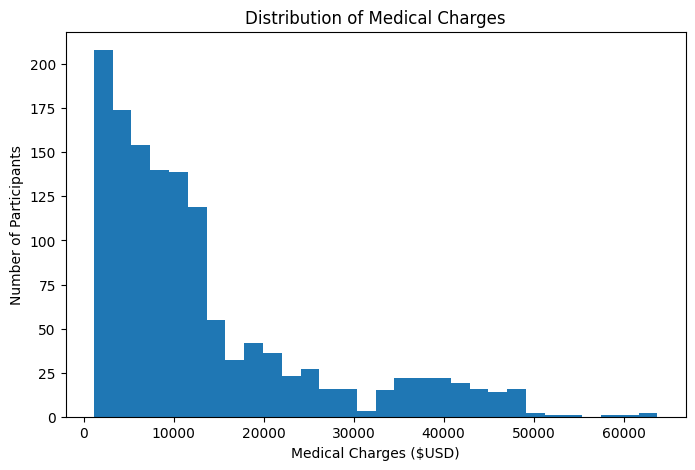

In [12]:
# Plot size
plt.figure(figsize=(8,5))

# Create histogram
plt.hist(insurance_df["charges"], bins=30)

# Plot labels
plt.title("Distribution of Medical Charges")
plt.xlabel("Medical Charges ($USD)")
plt.ylabel("Number of Participants")

# Display
plt.show()

### Interpretation

The distribution of medical charges is strongly right-skewed rather than normally distributed. We see that most participants incur relatively low medical charges, while a smaller group has substantially higher medical expenses.

The long right tail suggests that healthcare spending is not evenly distributed across the population. This pattern is common in healthcare data, where a relatively small percentage of individuals account for a disproportionately large portion of total medical costs.

Additionally, there appears to be a second concentration of observations between approximately **\$35,000** and **\$45,000**. This raises the possibility that the dataset contains distinct subgroups with different healthcare cost patterns. One hypothesis is that smoking status may contribute to this separation, although additional analysis is required to test this suspected relationship.

Because the target variable is not normally distributed, future predictive modeling may require evaluating whether transformations of the target variable improve model performance.

In [13]:
%pip install seaborn


[notice] A new release of pip is available: 26.1 -> 26.2
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [14]:
import seaborn as sns

## Medical Charges by Smoking Status

### Research Question

Do smokers incur higher medical charges than non-smokers?

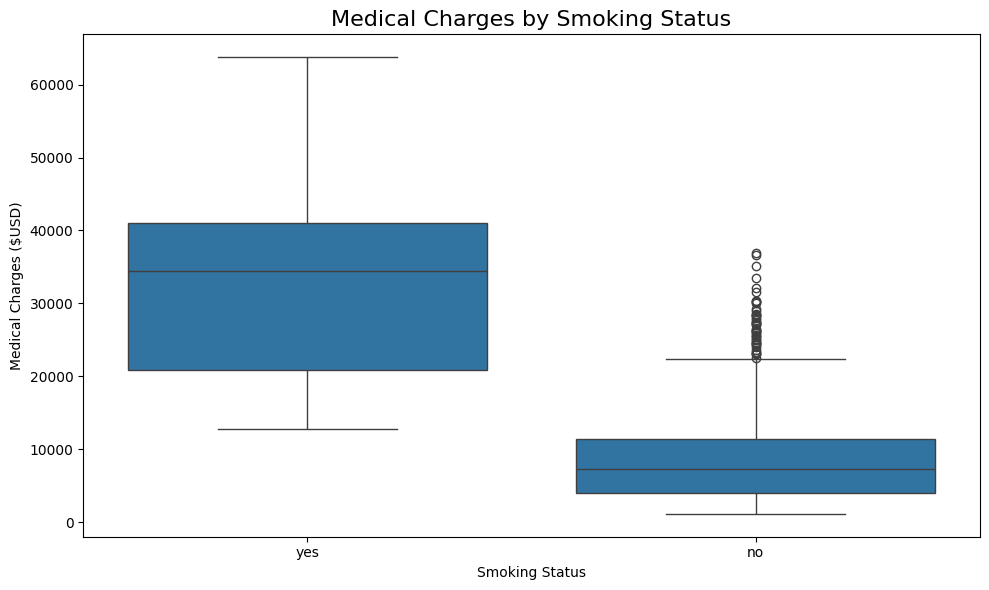

In [15]:
# Plot size
plt.figure(figsize=(10,6))

# Create boxplot using insurance_df with smoker as the independent variable (x) and charges as the dependent variable (y)
sns.boxplot(
    data=insurance_df,
    x="smoker",
    y="charges"
)

# Add Labels
plt.title("Medical Charges by Smoking Status", fontsize=16)
plt.xlabel("Smoking Status")
plt.ylabel("Medical Charges ($USD)")

# tight layout auto-spaces and prevents overlap
plt.tight_layout()
plt.show()

### Interpretation

The boxplot shows a substantial difference in medical charges between smokers and non-smokers. Smokers have a significantly higher median medical charge than non-smokers, indicating that smoking status is strongly associated with increased medical costs.

The smoker group also exhibits considerably greater variability in medical charges, as shown by a wider interquartile range and longer whiskers. This suggests that healthcare costs among smokers are not only higher on average but also more variable.

Although the non-smoker group contains numerous statistical outliers, these represent a relatively small number of individuals with unusually high healthcare costs compared to the rest of the non-smoking population.

Overall, smoking status appears to be one of the strongest candidate predictors of medical charges. This relationship will be investigated further during predictive modeling.

## Investigating the Relationship Between Age and Medical Charges

### Research Question

Is there a relationship between a participant's age and their medical insurance charges?

### Motivation

Age is often associated with increased healthcare utilization and chronic disease risk. This visualization explores whether medical charges tend to increase as participants get older.

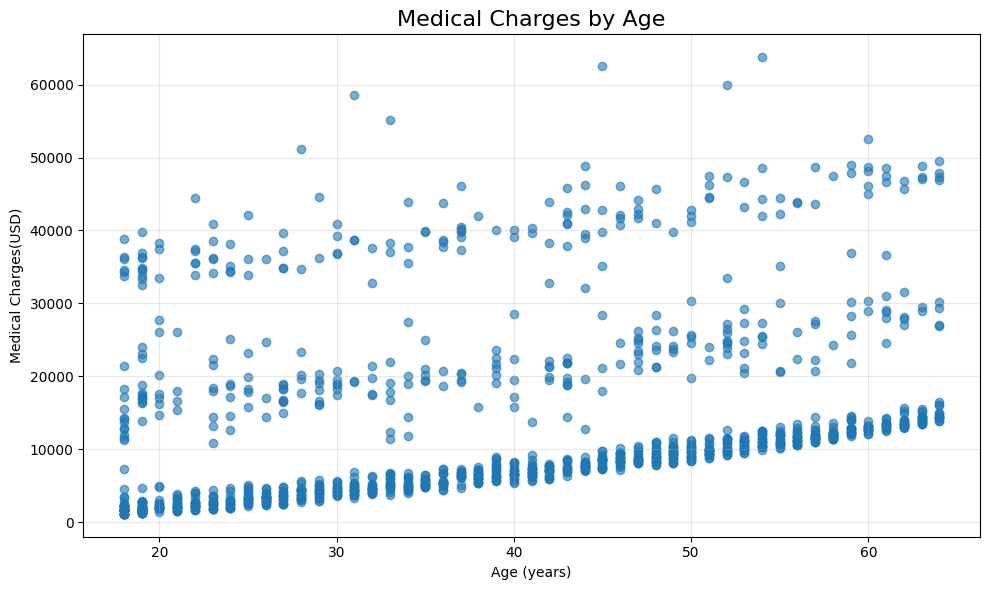

In [16]:
# Plot size
plt.figure(figsize=(10,6))

# Create Scatter Plot
plt.scatter(insurance_df["age"],
            insurance_df["charges"],
            alpha=0.6)

# Plot Labels
plt.title("Medical Charges by Age", fontsize = 16)
plt.xlabel("Age (years)")
plt.ylabel("Medical Charges(USD)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

The scatter plot suggests a positive relationship between age and medical insurance charges. In general, medical charges tend to increase as participants grow older, indicating that age is associated with increased healthcare costs.

However, age alone does not fully explain the variation in medical charges. Individuals of the same age often have substantially different healthcare costs, suggesting that additional variables contribute to medical expenses.

An interesting pattern is the presence of several distinct diagonal bands within the data. This may indicate underlying subgroups with different cost structures, potentially driven by factors such as smoking status or BMI. These relationships will be explored further through additional visualizations and predictive modeling.

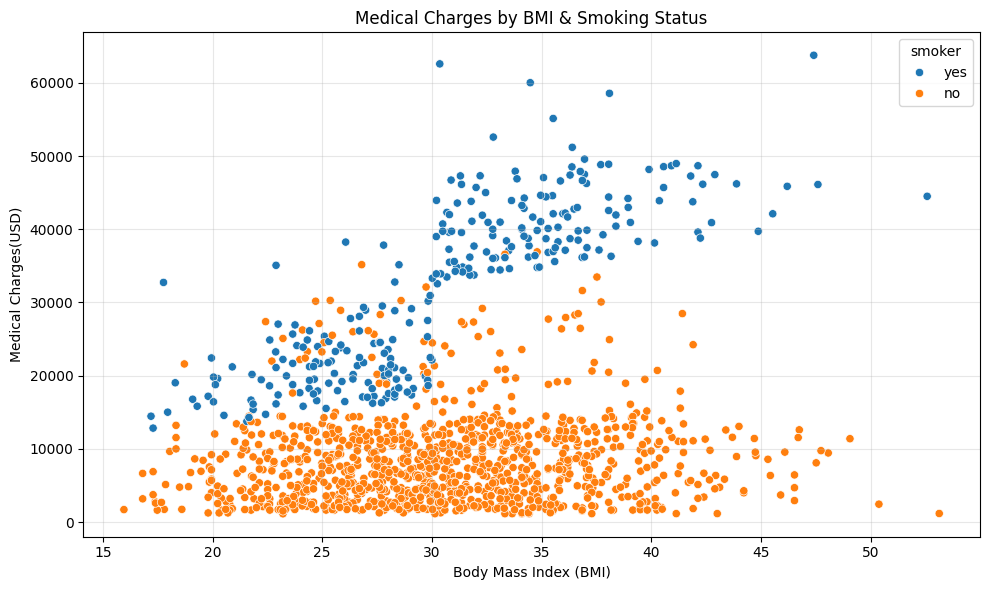

In [20]:
# Plot size
plt.figure(figsize=(10,6))

#Create Scatterplot
sns.scatterplot(
    data=insurance_df, 
    x="bmi",
    y="charges",
    hue="smoker")

# Plot Labels
plt.title("Medical Charges by BMI & Smoking Status")
plt.xlabel("Body Mass Index (BMI)")
plt.ylabel("Medical Charges(USD)")

# grid adjusts the weight of gridlines
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

This scatter plot reveals a clear separation between smokers and non-smokers. Participants who smoke generally incur substantially higher medical charges than non-smokers across nearly all BMI values.

BMI alone does not appear to fully explain medical charges. Individuals with similar BMI values often have dramatically different healthcare costs depending on their smoking status.

Among smokers, higher BMI appears to be associated with increased medical charges. In contrast, non-smokers generally maintain lower medical charges across the full range of BMI values.

These findings suggest that smoking status is a stronger predictor of medical charges than BMI alone. Additionally, the relationship between BMI and medical charges appears to differ depending on smoking status, indicating a possible interaction between these variables that should be investigated during predictive modeling.

## Correlation Analysis

### Research Question

Which numerical variables exhibit the strongest linear relationship with medical insurance charges?

### Motivation

Correlation analysis provides an initial assessment of the strength and direction of linear relationships between numerical variables. Although correlation does not imply causation, it can help identify variables that may be useful predictors in future machine learning models.

In [21]:
correlation_matrix = insurance_df.corr(numeric_only = True)
correlation_matrix

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


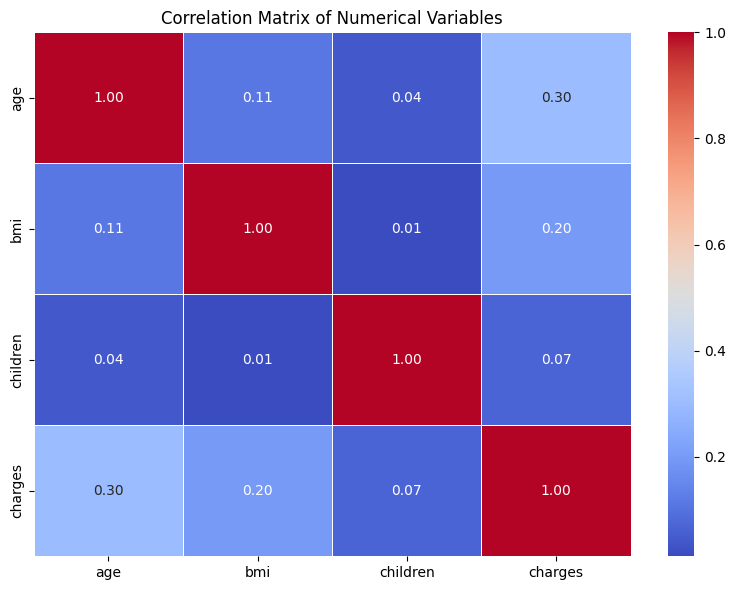

In [22]:
# Plot size
plt.figure(figsize=(8,6))

#Create Heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

# Plot Label
plt.title("Correlation Matrix of Numerical Variables")

plt.tight_layout()

plt.show()